In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter

## Batch stats

In [ ]:
# batch stats
before_str = '{"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1753476503237,"inference_count":12000,"execution_count":5730,"inference_stats":{"success":{"count":12000,"ns":68849374045556},"fail":{"count":0,"ns":0},"queue":{"count":12000,"ns":68576126469299},"compute_input":{"count":12000,"ns":7561447522},"compute_infer":{"count":12000,"ns":264717903106},"compute_output":{"count":12000,"ns":207704387},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":2740,"ns":204662524},"compute_infer":{"count":2740,"ns":14410697988},"compute_output":{"count":2740,"ns":33175223}},{"batch_size":2,"compute_input":{"count":2404,"ns":586955974},"compute_infer":{"count":2404,"ns":8535347857},"compute_output":{"count":2404,"ns":32087073}},{"batch_size":4,"compute_input":{"count":57,"ns":32556627},"compute_infer":{"count":57,"ns":11293860374},"compute_output":{"count":57,"ns":967306}},{"batch_size":6,"compute_input":{"count":4,"ns":4068605},"compute_infer":{"count":4,"ns":11175240030},"compute_output":{"count":4,"ns":99943}},{"batch_size":8,"compute_input":{"count":525,"ns":753529364},"compute_infer":{"count":525,"ns":15126203466},"compute_output":{"count":525,"ns":13235767}}],"memory_usage":[]}]}'
before_json = json.loads(before_str)


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
after_str = '{"model_stats":[{"name":"food_classifier_onnx","version":"1","last_inference":1753476527634,"inference_count":16000,"execution_count":8407,"inference_stats":{"success":{"count":16000,"ns":68870995066426},"fail":{"count":0,"ns":0},"queue":{"count":16000,"ns":68584951090921},"compute_input":{"count":16000,"ns":8324227922},"compute_infer":{"count":16000,"ns":276551715862},"compute_output":{"count":16000,"ns":260142442},"cache_hit":{"count":0,"ns":0},"cache_miss":{"count":0,"ns":0}},"response_stats":{},"batch_stats":[{"batch_size":1,"compute_input":{"count":4156,"ns":309487084},"compute_infer":{"count":4156,"ns":18550042450},"compute_output":{"count":4156,"ns":50453060}},{"batch_size":2,"compute_input":{"count":3634,"ns":881728664},"compute_infer":{"count":3634,"ns":12160053006},"compute_output":{"count":3634,"ns":48602916}},{"batch_size":4,"compute_input":{"count":88,"ns":49659242},"compute_infer":{"count":88,"ns":11405124873},"compute_output":{"count":88,"ns":1499439}},{"batch_size":6,"compute_input":{"count":4,"ns":4068605},"compute_infer":{"count":4,"ns":11175240030},"compute_output":{"count":4,"ns":99943}},{"batch_size":8,"compute_input":{"count":525,"ns":753529364},"compute_infer":{"count":525,"ns":15126203466},"compute_output":{"count":525,"ns":13235767}}],"memory_usage":[]}]}'
after_json = json.loads(after_str)


In [ ]:
#before_json = json.load(open('/content/drive/My Drive/Summer 2025 Research/tracing 1000 reqs/run 3/r3_t1_before_stats.json'))
#after_json = json.load(open('/content/drive/My Drive/Summer 2025 Research/tracing 1000 reqs/run 3/r3_t1_after_stats.json'))

In [ ]:
before_arr  = np.zeros(8, dtype='int')
before_ts   = np.zeros(8, dtype='int')
for batch in before_json['model_stats'][0]['batch_stats']:
  before_arr[batch['batch_size']-1] = batch['compute_infer']['count']
  before_ts[batch['batch_size']-1]  = batch['compute_infer']['ns']

after_arr  = np.zeros(8, dtype='int')
after_ts   = np.zeros(8, dtype='int')
for batch in after_json['model_stats'][0]['batch_stats']:
  after_arr[batch['batch_size']-1] = batch['compute_infer']['count']
  after_ts[batch['batch_size']-1]  = batch['compute_infer']['ns']


In [ ]:
counts = after_arr - before_arr

In [ ]:
counts

array([1416, 1230,    0,   31,    0,    0,    0,    0])

In [ ]:
times = (after_ts - before_ts)/1e6

In [ ]:
times

array([4139.344462, 3624.705149,    0.      ,  111.264499,    0.      ,
          0.      ,    0.      ,    0.      ])

### ✅ There are batched requests?

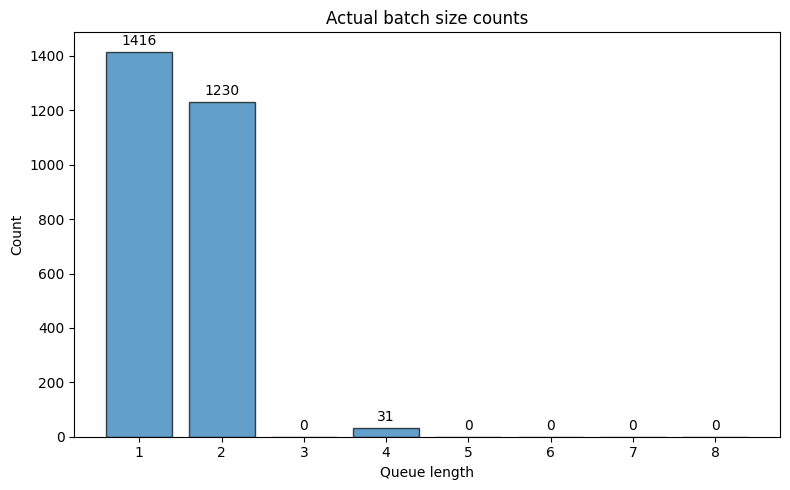

In [ ]:
x = np.arange(1, 9)
y = after_arr - before_arr

plt.figure(figsize=(8, 5))
bars = plt.bar(x=x, height=y, edgecolor='black', alpha=0.7)

for xi, yi in zip(x, y):
    plt.text(xi, yi + max(y)*0.01, str(int(yi)), ha='center', va='bottom', fontsize=10)

plt.title('Actual batch size counts')
plt.xlabel('Queue length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### ✅ The compute time is reasonable?

## ❌ Average inference time according to batch stats doesn't match

In [ ]:
np.sum(times)/np.sum(counts)

np.float64(2.941843149047441)

In [ ]:
x = np.arange(1, 9)
y = np.nan_to_num(np.divide((after_ts - before_ts)/1e6, after_arr - before_arr), nan=0.0)


/tmp/ipython-input-13-4022362538.py:2: RuntimeWarning: invalid value encountered in divide
  y = np.nan_to_num(np.divide((after_ts - before_ts)/1e6, after_arr - before_arr), nan=0.0)


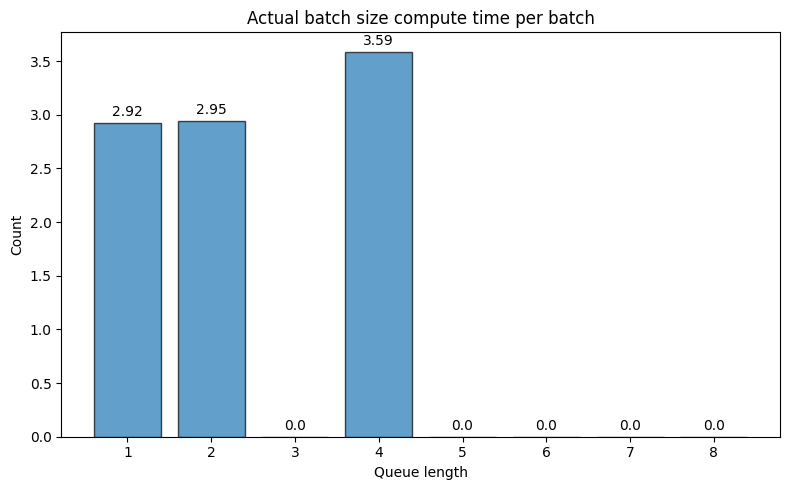

In [ ]:

plt.figure(figsize=(8, 5))
bars = plt.bar(x=x, height=y, edgecolor='black', alpha=0.7)

for xi, yi in zip(x, y):
    plt.text(xi, yi + max(y)*0.01, str(round(yi, 2)), ha='center', va='bottom', fontsize=10)

plt.title('Actual batch size compute time per batch')
plt.xlabel('Queue length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### ✅ There are exactly the expected number of requests?

In [ ]:
np.sum((after_arr - before_arr)*np.arange(1,8+1)) # should sum to 4000

np.int64(4000)

## Trace summary tool

In [ ]:
!wget https://raw.githubusercontent.com/triton-inference-server/server/refs/heads/main/qa/common/trace_summary.py -O trace_summary.py

--2025-07-25 21:04:41--  https://raw.githubusercontent.com/triton-inference-server/server/refs/heads/main/qa/common/trace_summary.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17919 (17K) [text/plain]
Saving to: ‘trace_summary.py’

trace_summary.py    100%[===================>]  17.50K  --.-KB/s    in 0.001s  

2025-07-25 21:04:41 (13.0 MB/s) - ‘trace_summary.py’ saved [17919/17919]



### ✅ Trace summary shows similar number of requests, compute infer time?

In [ ]:
!python3 trace_summary.py "/content/drive/My Drive/Summer 2025 Research/tracing 1000 reqs/run 6/trace_r6_3.json"

File: /content/drive/My Drive/Summer 2025 Research/tracing 1000 reqs/run 6/trace_r6_3.json
Summary for food_classifier_onnx (1): trace count = 4000
HTTP infer request (avg): 8351.16010175us
	Receive (avg): 2865.8026355us
	Send (avg): 8.0948035us
	Overhead (avg): 70.162596us

	Handler (avg): 5407.10006675us
		Overhead (avg): 38.6868585us
		Queue (avg): 2206.1554055us
		Compute (avg): 3162.25780275us
			Input (avg): 190.6951us
			Infer (avg): 2958.453189us
			Output (avg): 13.10951375us


## Trace preliminary data processing


In [ ]:
with open("/content/drive/My Drive/Summer 2025 Research/tracing 1000 reqs/run 6/trace_r6_3.json",'r') as j:
  contents = json.loads(j.read())

In [ ]:
min_ts = contents[0]['timestamps'][0]['ns']/1e6

In [ ]:
#get unique sample ids
sids = np.unique([contents[i]['id'] for i in range(len(contents))])

In [ ]:
sids[:5]

array([12001, 12002, 12003, 12004, 12005])

In [ ]:
samples = []
#for each sample get the event names and timestamps (ms) from the moment the first req arrives (min_ts)
#put all samples in a list - each sample has tuples (event, timestamp(ms))
for sidx in sids:
    s = [(contents[i]['timestamps'][0]['name'], contents[i]['timestamps'][0]['ns']/1e6 - min_ts) for i in range(len(contents)) if contents[i]['id']==sidx and 'timestamps' in contents[i].keys()]
    samples.append(s)

In [ ]:
#i want a list of dictionaries {'id': REQUESTID, 'name': EVENTNAME, 'time_ms': TIMESTAMP_MS}
event_list = []
for i in range(len(samples)):
  for event in samples[i]:
    new_dict = {'id':i, 'name':event[0], 'time_ms':event[1]}
    event_list.append(new_dict)


In [ ]:
#sorting all events based on their timestamps
event_list.sort(key=lambda x: x['time_ms'])

In [ ]:
event_list[:5]

[{'id': 0, 'name': 'HTTP_RECV_START', 'time_ms': 0.0},
 {'id': 0, 'name': 'HTTP_RECV_END', 'time_ms': 1.8777499794960022},
 {'id': 0, 'name': 'REQUEST_START', 'time_ms': 1.9779709875583649},
 {'id': 0, 'name': 'QUEUE_START', 'time_ms': 1.9875510036945343},
 {'id': 0, 'name': 'COMPUTE_START', 'time_ms': 2.0625849962234497}]

In [ ]:
samples_dict = []

for sidx in sids:
    sample_dict = {
        contents[i]['timestamps'][0]['name']: contents[i]['timestamps'][0]['ns'] / 1e6 - min_ts
        for i in range(len(contents))
        if contents[i]['id'] == sidx and 'timestamps' in contents[i]
    }
    samples_dict.append(sample_dict)


## Timeline visualizations

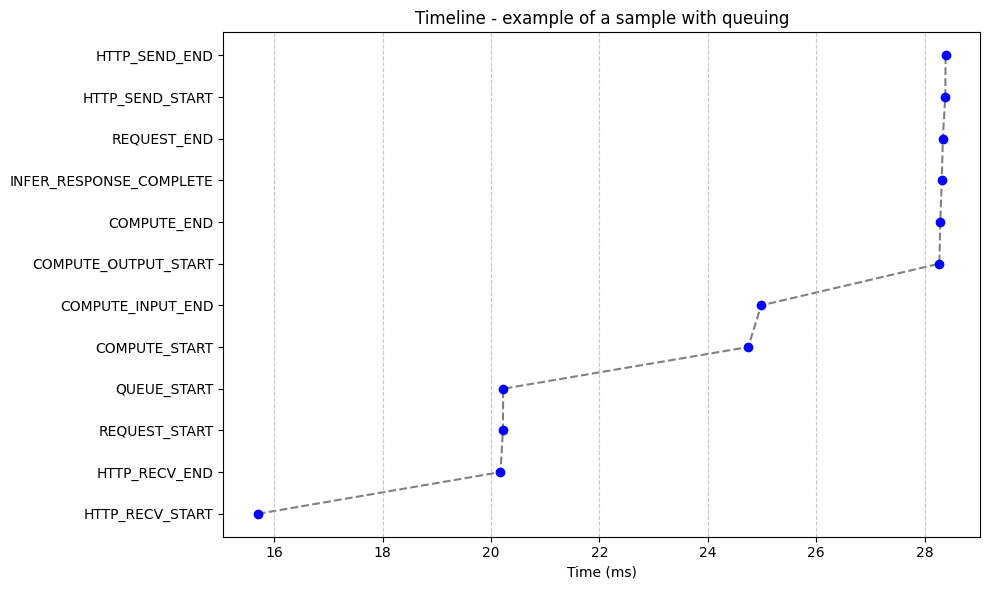

In [ ]:
events_dict = samples_dict[6]
events_sorted = sorted(events_dict.items(), key=lambda x: x[1])
event_names, times = zip(*events_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(times, event_names, color='blue', zorder=5)
plt.plot(times, event_names, linestyle='--', color='gray', zorder=1)

plt.xlabel("Time (ms)")
plt.title("Timeline - example of a sample with queuing")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


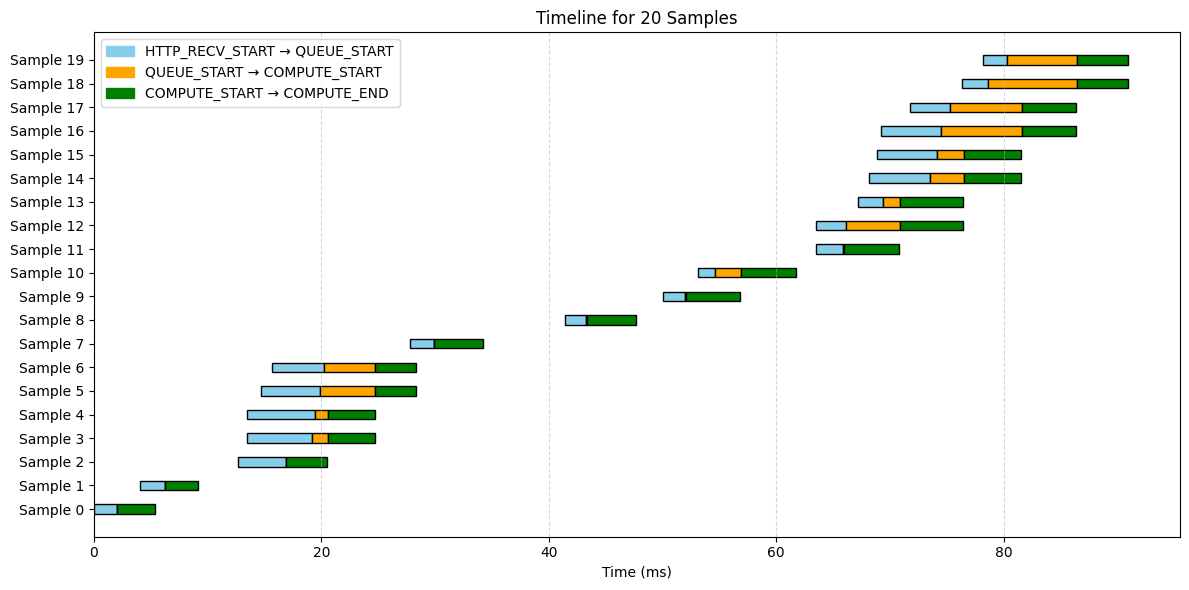

In [ ]:
import matplotlib.pyplot as plt

n_samples = 20

# Define the segments and their colors
phases = [
    ('HTTP_RECV_START', 'QUEUE_START', 'skyblue'),
    ('QUEUE_START', 'COMPUTE_START', 'orange'),
    ('COMPUTE_START', 'COMPUTE_END', 'green')
]

plt.figure(figsize=(12, 6))

# Plot first 5 samples
for idx in range(n_samples):
    sample = samples_dict[idx]

    for start_event, end_event, color in phases:
        start_time = sample[start_event]
        end_time = sample[end_event]
        duration = end_time - start_time
        plt.barh(y=idx, width=duration, left=start_time, height=0.4, color=color, edgecolor='black')

# Y-axis settings
plt.yticks(range(n_samples), [f"Sample {i}" for i in range(n_samples)])
plt.xlabel("Time (ms)")
plt.title(f"Timeline for {n_samples} Samples")

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color, label=f"{start} → {end}") for start, end, color in phases]
plt.legend(handles=legend_patches, loc='upper left')

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


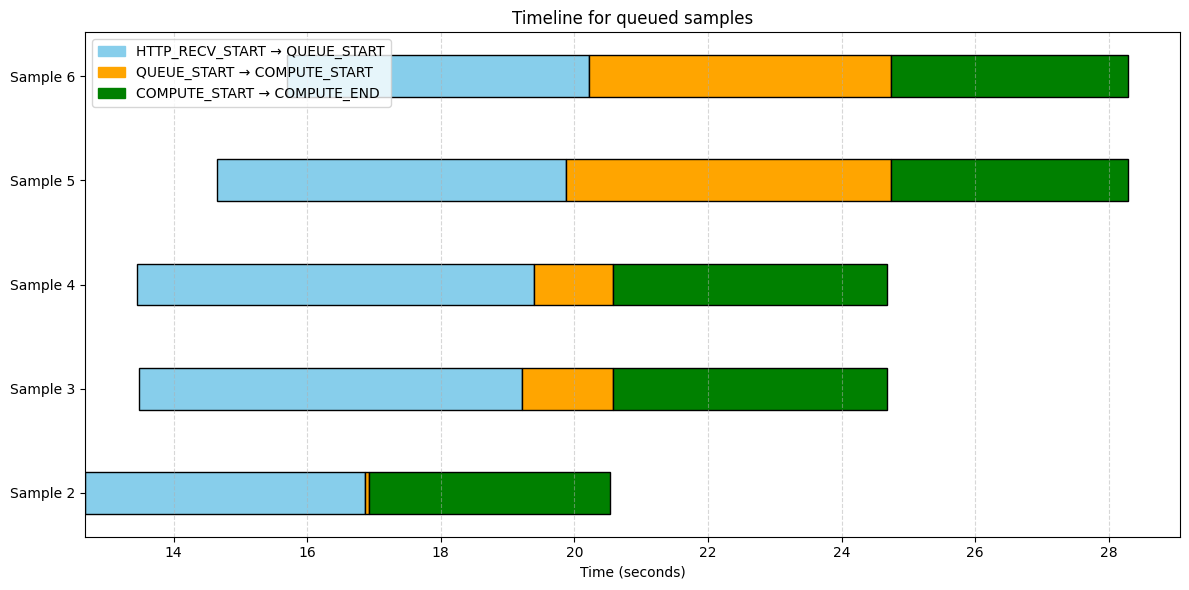

In [ ]:
import matplotlib.pyplot as plt

n_samples = 5
offset = 2

# Define the segments and their colors
phases = [
    ('HTTP_RECV_START', 'QUEUE_START', 'skyblue'),
    ('QUEUE_START', 'COMPUTE_START', 'orange'),
    ('COMPUTE_START', 'COMPUTE_END', 'green')
]

plt.figure(figsize=(12, 6))

# Plot first 5 samples
for idx in range(n_samples):
    sample = samples_dict[idx+offset]

    for start_event, end_event, color in phases:
        start_time = sample[start_event]
        end_time = sample[end_event]
        duration = end_time - start_time
        plt.barh(y=idx, width=duration, left=start_time, height=0.4, color=color, edgecolor='black')

# Y-axis settings
plt.yticks(range(n_samples), [f"Sample {i+offset}" for i in range(n_samples)])
plt.xlabel("Time (seconds)")
plt.title(f"Timeline for queued samples")

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color, label=f"{start} → {end}") for start, end, color in phases]
plt.legend(handles=legend_patches, loc='upper left')

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


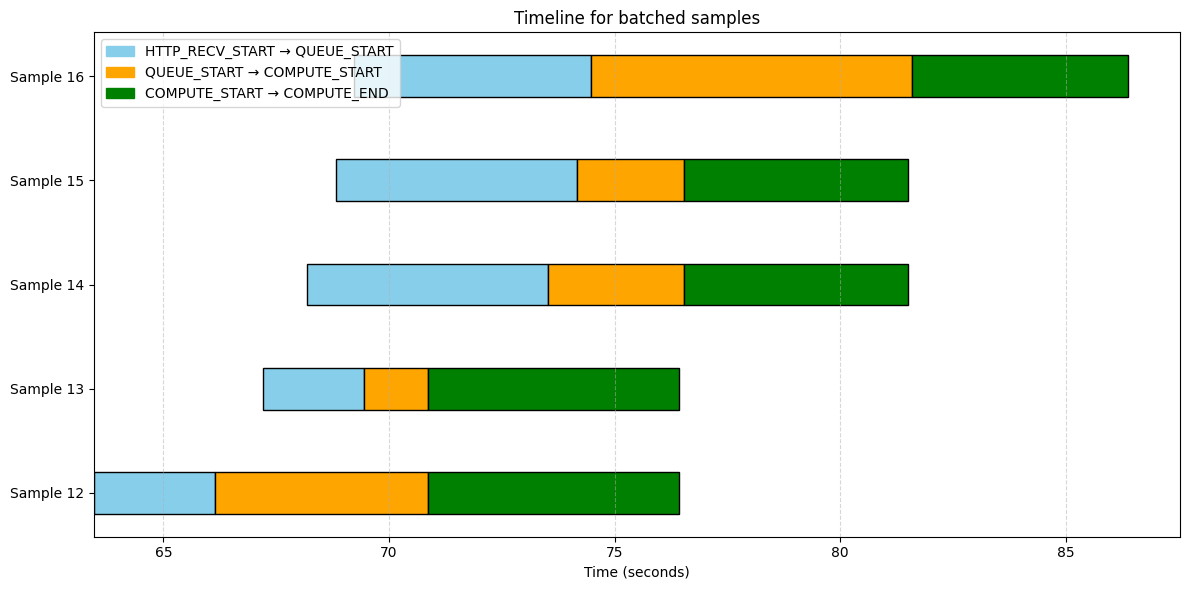

In [ ]:
import matplotlib.pyplot as plt

n_samples = 5
offset = 12

# Define the segments and their colors
phases = [
    ('HTTP_RECV_START', 'QUEUE_START', 'skyblue'),
    ('QUEUE_START', 'COMPUTE_START', 'orange'),
    ('COMPUTE_START', 'COMPUTE_END', 'green')
]

plt.figure(figsize=(12, 6))

# Plot first 5 samples
for idx in range(n_samples):
    sample = samples_dict[idx+offset]

    for start_event, end_event, color in phases:
        start_time = sample[start_event]
        end_time = sample[end_event]
        duration = end_time - start_time
        plt.barh(y=idx, width=duration, left=start_time, height=0.4, color=color, edgecolor='black')

# Y-axis settings
plt.yticks(range(n_samples), [f"Sample {i+offset}" for i in range(n_samples)])
plt.xlabel("Time (seconds)")
plt.title(f"Timeline for batched samples")

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color, label=f"{start} → {end}") for start, end, color in phases]
plt.legend(handles=legend_patches, loc='upper left')

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
samples_dict[14]['COMPUTE_START']

76.53239899873734

In [ ]:
samples_dict[15]['COMPUTE_START']

76.53239899873734

In [ ]:
samples_dict[16]['COMPUTE_START']

81.60294798016548

Looking at this, the condition for "batched together" is: they `COMPUTE_START` together.

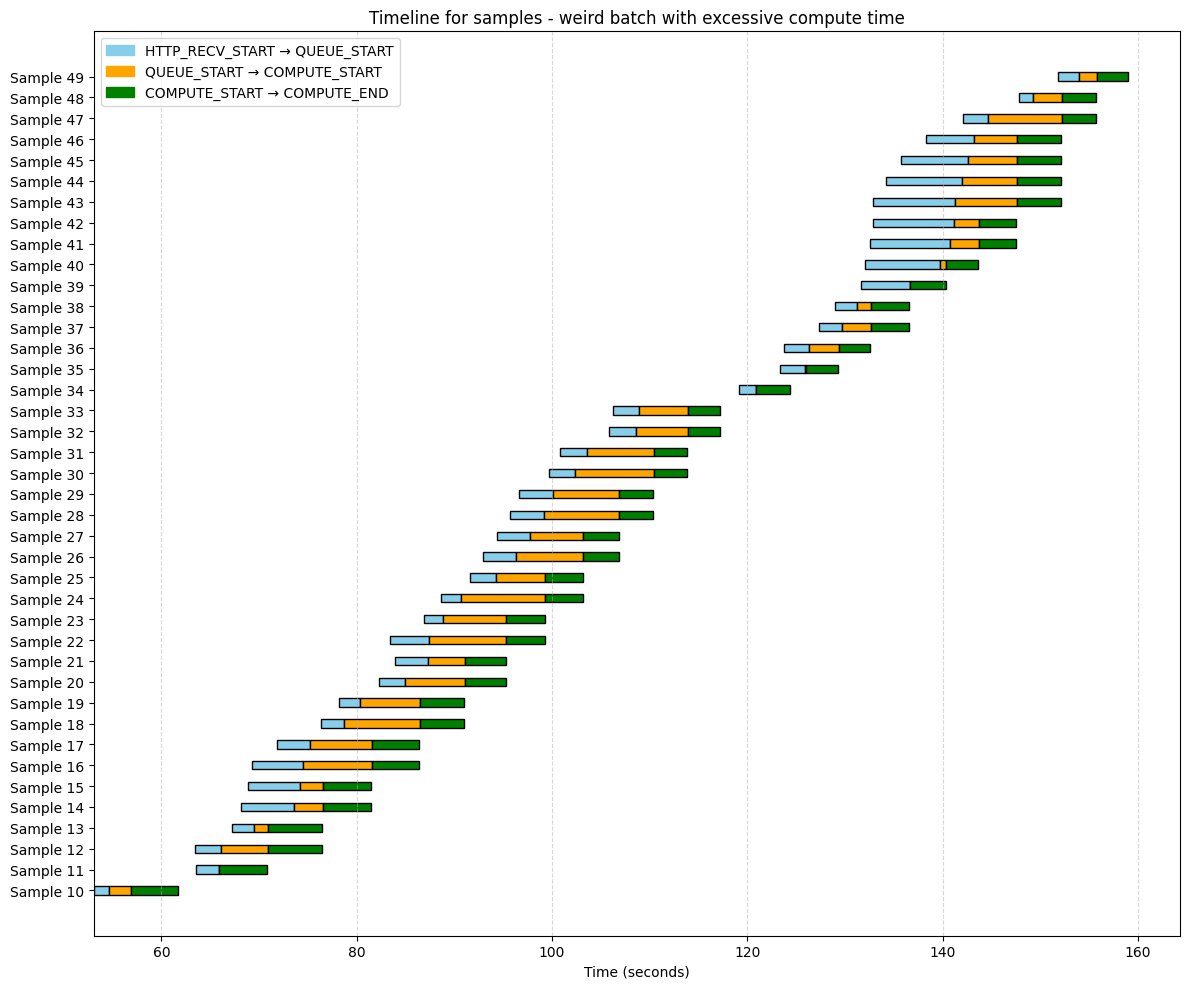

In [ ]:
import matplotlib.pyplot as plt

n_samples = 40
offset = 10

# Define the segments and their colors
phases = [
    ('HTTP_RECV_START', 'QUEUE_START', 'skyblue'),
    ('QUEUE_START', 'COMPUTE_START', 'orange'),
    ('COMPUTE_START', 'COMPUTE_END', 'green')
]

plt.figure(figsize=(12, 10))

# Plot first 5 samples
for idx in range(n_samples):
    sample = samples_dict[idx+offset]

    for start_event, end_event, color in phases:
        start_time = sample[start_event]
        end_time = sample[end_event]
        duration = end_time - start_time
        plt.barh(y=idx, width=duration, left=start_time, height=0.4, color=color, edgecolor='black')

# Y-axis settings
plt.yticks(range(n_samples), [f"Sample {i+offset}" for i in range(n_samples)])
plt.xlabel("Time (seconds)")
plt.title(f"Timeline for samples - weird batch with excessive compute time")

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color, label=f"{start} → {end}") for start, end, color in phases]
plt.legend(handles=legend_patches, loc='upper left')

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

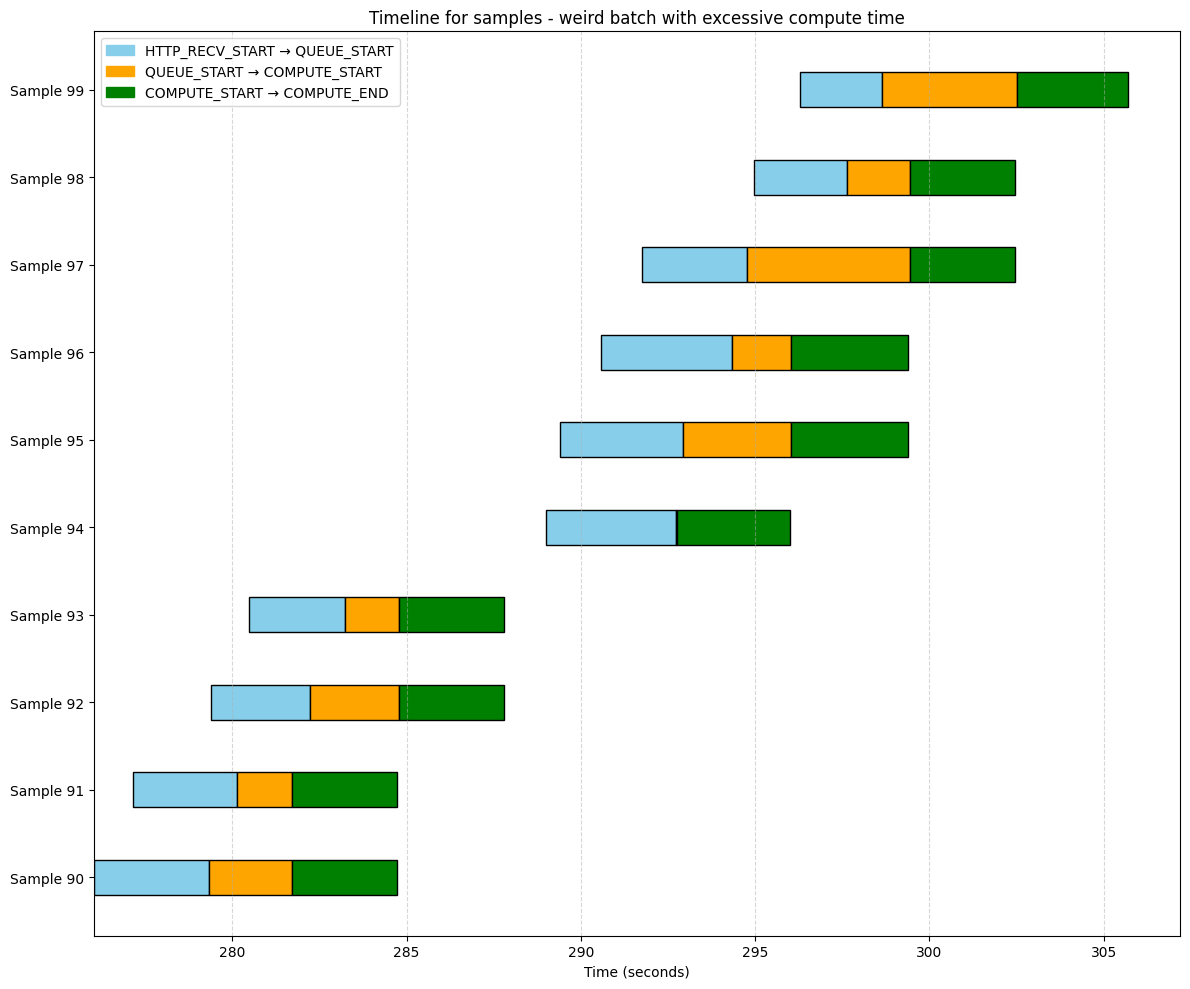

In [ ]:
import matplotlib.pyplot as plt

n_samples = 10
offset = 90

# Define the segments and their colors
phases = [
    ('HTTP_RECV_START', 'QUEUE_START', 'skyblue'),
    ('QUEUE_START', 'COMPUTE_START', 'orange'),
    ('COMPUTE_START', 'COMPUTE_END', 'green')
]

plt.figure(figsize=(12, 10))

# Plot first 5 samples
for idx in range(n_samples):
    sample = samples_dict[idx+offset]

    for start_event, end_event, color in phases:
        start_time = sample[start_event]
        end_time = sample[end_event]
        duration = end_time - start_time
        plt.barh(y=idx, width=duration, left=start_time, height=0.4, color=color, edgecolor='black')

# Y-axis settings
plt.yticks(range(n_samples), [f"Sample {i+offset}" for i in range(n_samples)])
plt.xlabel("Time (seconds)")
plt.title(f"Timeline for samples - weird batch with excessive compute time")

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color, label=f"{start} → {end}") for start, end, color in phases]
plt.legend(handles=legend_patches, loc='upper left')

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
samples_dict[28]

{'HTTP_RECV_START': 95.65985098481178,
 'HTTP_RECV_END': 99.10814598202705,
 'REQUEST_START': 99.16770899295807,
 'QUEUE_START': 99.17229899764061,
 'INFER_RESPONSE_COMPLETE': 110.38037598133087,
 'COMPUTE_START': 106.87310698628426,
 'COMPUTE_INPUT_END': 107.12772998213768,
 'COMPUTE_OUTPUT_START': 110.35464999079704,
 'COMPUTE_END': 110.36971598863602,
 'REQUEST_END': 110.40853798389435,
 'HTTP_SEND_START': 110.40971699357033,
 'HTTP_SEND_END': 110.42392098903656}

In [ ]:
samples_dict[29]

{'HTTP_RECV_START': 96.56324699521065,
 'HTTP_RECV_END': 99.99508500099182,
 'REQUEST_START': 100.05241298675537,
 'QUEUE_START': 100.05714899301529,
 'INFER_RESPONSE_COMPLETE': 110.39721900224686,
 'COMPUTE_START': 106.87310698628426,
 'COMPUTE_INPUT_END': 107.12772998213768,
 'COMPUTE_OUTPUT_START': 110.35464999079704,
 'COMPUTE_END': 110.36971598863602,
 'REQUEST_END': 110.41725197434425,
 'HTTP_SEND_START': 110.44105398654938,
 'HTTP_SEND_END': 110.44678798317909}

This is weird.

It also agrees with batch stats which say that batch of size 2 and batch size of 6 had long compute time.

### ✅ Timeline doesn't show anything crazy???

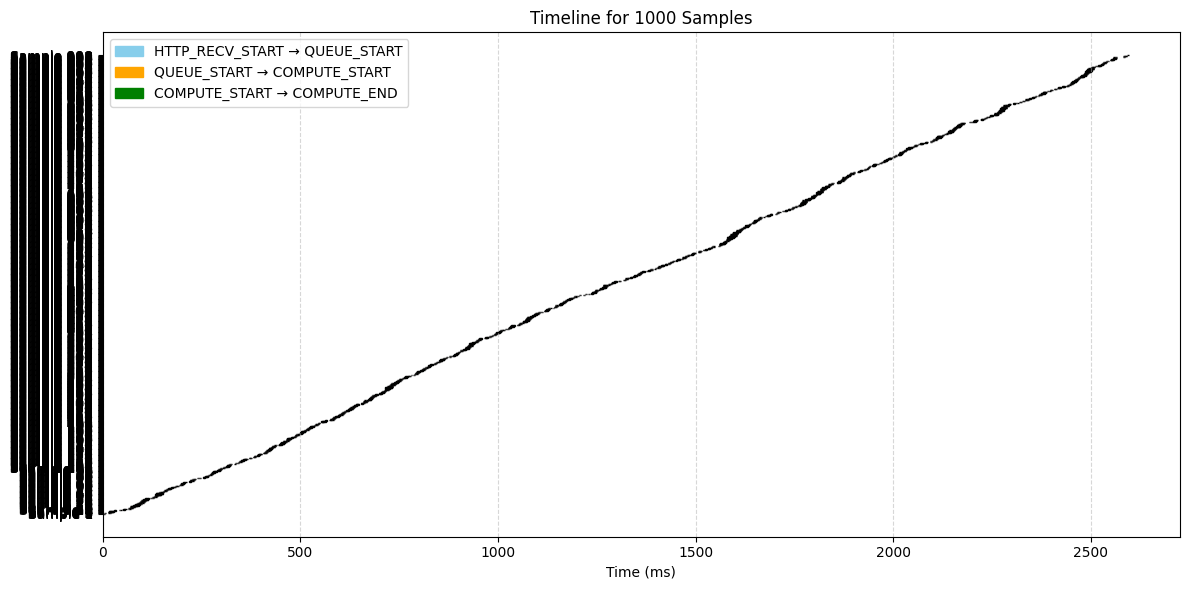

In [ ]:
import matplotlib.pyplot as plt

n_samples = 1000

# Define the segments and their colors
phases = [
    ('HTTP_RECV_START', 'QUEUE_START', 'skyblue'),
    ('QUEUE_START', 'COMPUTE_START', 'orange'),
    ('COMPUTE_START', 'COMPUTE_END', 'green')
]

plt.figure(figsize=(12, 6))

# Plot first 5 samples
for idx in range(n_samples):
    sample = samples_dict[idx]

    for start_event, end_event, color in phases:
        start_time = sample[start_event]
        end_time = sample[end_event]
        duration = end_time - start_time
        plt.barh(y=idx, width=duration, left=start_time, height=0.4, color=color, edgecolor='black')

# Y-axis settings
plt.yticks(range(n_samples), [f"Sample {i}" for i in range(n_samples)])
plt.xlabel("Time (ms)")
plt.title(f"Timeline for {n_samples} Samples")

# Legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color, label=f"{start} → {end}") for start, end, color in phases]
plt.legend(handles=legend_patches, loc='upper left')

plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Get batch sizes from trace

In [ ]:
counts

array([1416, 1230,    0,   31,    0,    0,    0,    0])

In [ ]:
compute_start_times = np.array([
    sample['COMPUTE_START'] for sample in samples_dict if 'COMPUTE_START' in sample
])
unique_times, counts = np.unique(compute_start_times, return_counts=True)


### ✅ Batch size dist from trace matches batch stats

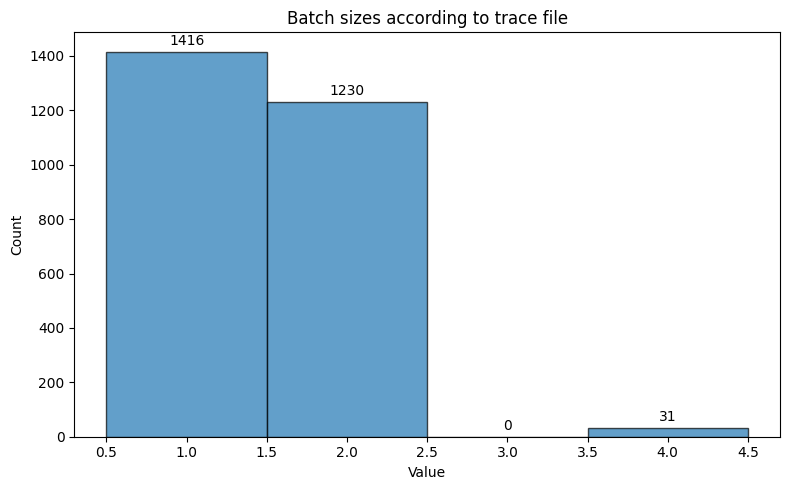

In [ ]:
plt.figure(figsize=(8, 5))

n, bins, patches = plt.hist(counts, bins=np.arange(min(counts), max(counts)+2),
                            edgecolor='black', align='left', alpha=0.7)

for xi, yi in zip(bins[:-1], n):
    plt.text(xi, yi + max(n)*0.01, str(int(yi)), ha='center', va='bottom', fontsize=10)

plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Batch sizes according to trace file")
plt.tight_layout()
plt.show()

# Interarrival Time Distribution

In [ ]:
arrivals = []
for i in range(len(event_list)):
  if event_list[i]['name'] == 'HTTP_RECV_START':
    arrivals.append(event_list[i]['time_ms'])

In [ ]:
interarrival_times = np.diff(arrivals)
print(interarrival_times)

[4.05508599 8.61995199 0.77732602 ... 2.386177   0.43289798 3.15799102]


### ✅ Interarrival time looks exp with expected mean?

In [ ]:
interarrival_times.mean()

np.float64(2.5375889029747905)

In [ ]:
rps = 1/(interarrival_times.mean()*1e-3)
rps   # arrivals per second - should match what you set

np.float64(394.0748632797495)

In [ ]:
rps*1e-3

np.float64(0.3940748632797495)

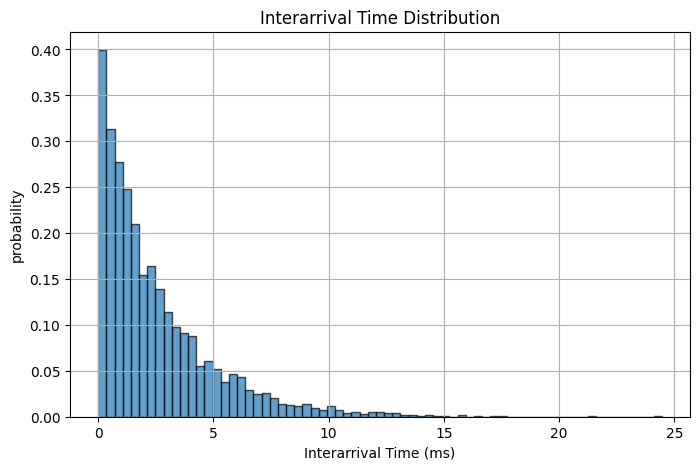

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(interarrival_times, bins='auto',density=True, edgecolor='black', alpha=0.7)
plt.title('Interarrival Time Distribution')
plt.xlabel('Interarrival Time (ms)')
plt.ylabel('probability')
plt.grid(True)
plt.show()

In [ ]:
# numpy way to compute them

interarrival_times = np.zeros(len(samples_dict) - 1)

# Fill in the array
for i in range(len(samples_dict) - 1):
    interarrival_times[i] = (
        samples_dict[i + 1]['HTTP_RECV_START'] - samples_dict[i]['HTTP_RECV_START']
    )

# Service Time Distribution

In [ ]:
compute_start = []
compute_end = []
for i in range(len(event_list)):
  if event_list[i]['name'] == 'COMPUTE_START':
    compute_start.append(event_list[i]['time_ms'])
  elif event_list[i]['name'] == 'COMPUTE_END':
    compute_end.append(event_list[i]['time_ms'])

service_times = [compute_end[i] - compute_start[i] for i in range(len(compute_start))]

In [ ]:
service_times

[3.2728749811649323,
 2.8754779994487762,
 3.6136940121650696,
 4.093767017126083,
 4.093767017126083,
 3.542490005493164,
 3.542490005493164,
 4.32007098197937,
 4.36081799864769,
 4.807458996772766,
 4.809143990278244,
 4.86583599448204,
 5.562142997980118,
 5.562142997980118,
 4.971062988042831,
 4.971062988042831,
 4.785080999135971,
 4.785080999135971,
 4.487874984741211,
 4.487874984741211,
 4.182014018297195,
 4.182014018297195,
 3.939432978630066,
 3.939432978630066,
 3.8013289868831635,
 3.8013289868831635,
 3.6088519990444183,
 3.6088519990444183,
 3.496609002351761,
 3.496609002351761,
 3.404087007045746,
 3.404087007045746,
 3.281887024641037,
 3.281887024641037,
 3.3983629941940308,
 3.320961982011795,
 3.266555994749069,
 3.878946006298065,
 3.878946006298065,
 3.670399993658066,
 3.257732003927231,
 3.8758209943771362,
 3.8758209943771362,
 4.516378998756409,
 4.516378998756409,
 4.516378998756409,
 4.516378998756409,
 3.5004810094833374,
 3.5004810094833374,
 3.21869599

### ✅ Service times are pretty close to the mean we used?

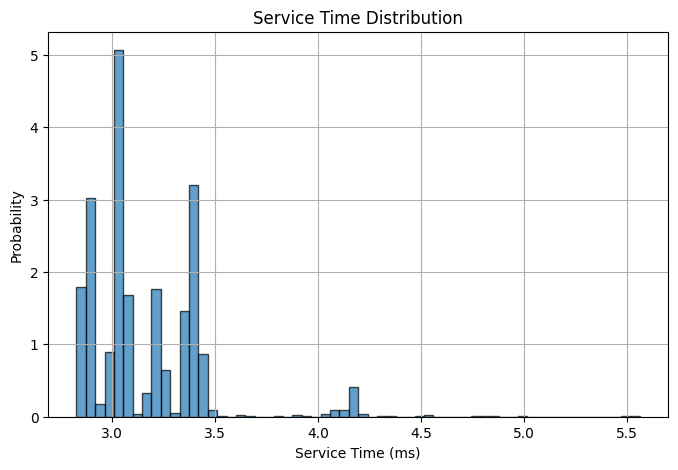

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(service_times, bins='auto', density=True, edgecolor='black', alpha=0.7)
plt.title('Service Time Distribution')
plt.xlabel('Service Time (ms)')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

In [ ]:
service_times = np.zeros(len(samples_dict) - 1)

# Fill in the array
for i in range(len(samples_dict) - 1):
    service_times[i] = (
        samples_dict[i]['COMPUTE_END'] - samples_dict[i]['COMPUTE_START']
    )


In [ ]:
service_times

array([3.27287498, 2.875478  , 3.61369401, ..., 3.04542398, 3.04542398,
       3.04670498])

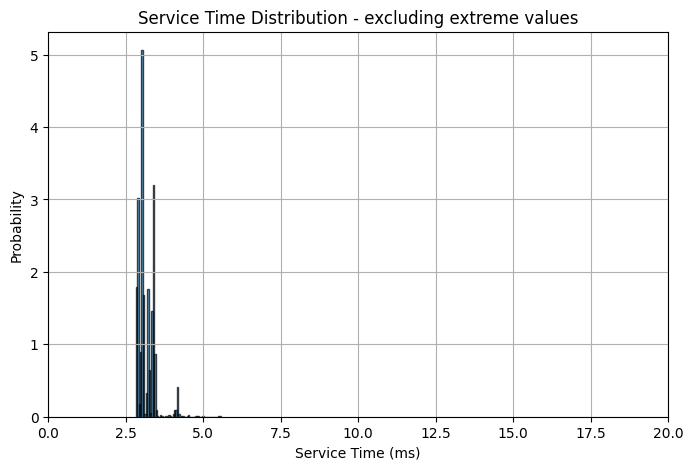

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(service_times, bins='auto', density=True, edgecolor='black', alpha=0.7)
plt.title('Service Time Distribution - excluding extreme values')
plt.xlabel('Service Time (ms)')
plt.ylabel('Probability')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

In [ ]:
service_times.mean() # mean service time

np.float64(3.162286698236916)

In [ ]:
np.quantile(service_times, q=[0.5]) # median service time

array([3.05510199])

# Queue Time Distribution

In [ ]:
queue_times = np.zeros(len(samples_dict) - 1)

# Fill in the array
for i in range(len(samples_dict) - 1):
    queue_times[i] = (
        samples_dict[i]['COMPUTE_START'] - samples_dict[i]['QUEUE_START']
    )


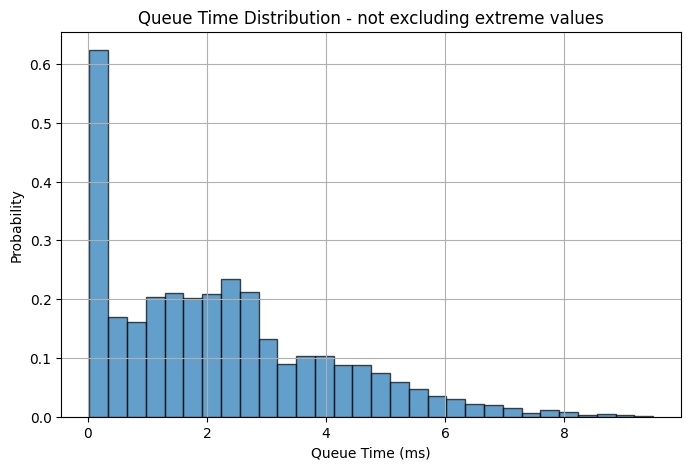

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(queue_times, bins='auto', density=True, edgecolor='black', alpha=0.7)
plt.title('Queue Time Distribution - not excluding extreme values')
plt.xlabel('Queue Time (ms)')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

In [ ]:
queue_times.mean() # average queue time

np.float64(2.206362850086544)

In [ ]:
np.quantile(queue_times, q=[0.5]) # median queue time

array([1.93496799])

## Queue size

In [ ]:
event_list[0]

{'id': 0, 'name': 'HTTP_RECV_START', 'time_ms': 0.0}

In [ ]:
queue_size_dict = []
queue_size = 0

queue_size_dict.append({'time_ms': 0, 'size': queue_size})

for event in event_list:
  if event['name'] == 'QUEUE_START':
    queue_size += 1
    queue_size_dict.append({'time_ms': event['time_ms'], 'size': queue_size})
  elif event['name'] == 'COMPUTE_START':
    queue_size -= 1
    queue_size_dict.append({'time_ms': event['time_ms'], 'size': queue_size})

Confirm that we start at 0 and end at 0:

In [ ]:
queue_size_dict[0], queue_size_dict[-1]

({'time_ms': 0, 'size': 0}, {'time_ms': 10150.49802300334, 'size': 0})

In [ ]:
len(queue_size_dict)

8001

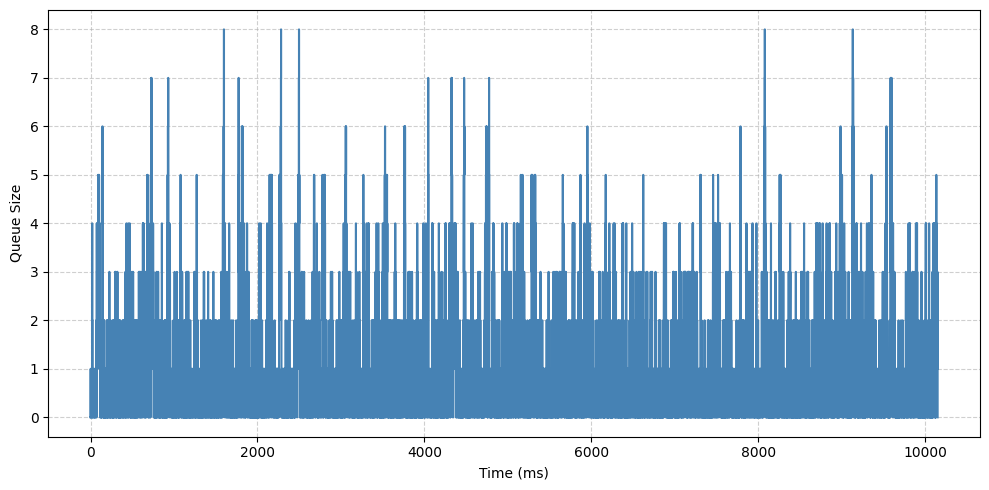

In [ ]:
times = [entry['time_ms'] for entry in queue_size_dict]
sizes = [entry['size'] for entry in queue_size_dict]

plt.figure(figsize=(10, 5))
plt.step(times, sizes, where='post', color='steelblue')

plt.xlabel("Time (ms)")
plt.ylabel("Queue Size")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


This is a better way because it groups together requests that are de-queued together.

In [ ]:
from collections import defaultdict

delta_by_time = defaultdict(int)

for event in event_list:
    if event['name'] == 'QUEUE_START':
        delta_by_time[event['time_ms']] += 1
    elif event['name'] == 'COMPUTE_START':
        delta_by_time[event['time_ms']] -= 1

queue_size_dict = []
queue_size = 0

for time_ms in sorted(delta_by_time):
    queue_size += delta_by_time[time_ms]
    queue_size_dict.append({'time_ms': time_ms, 'size': queue_size})


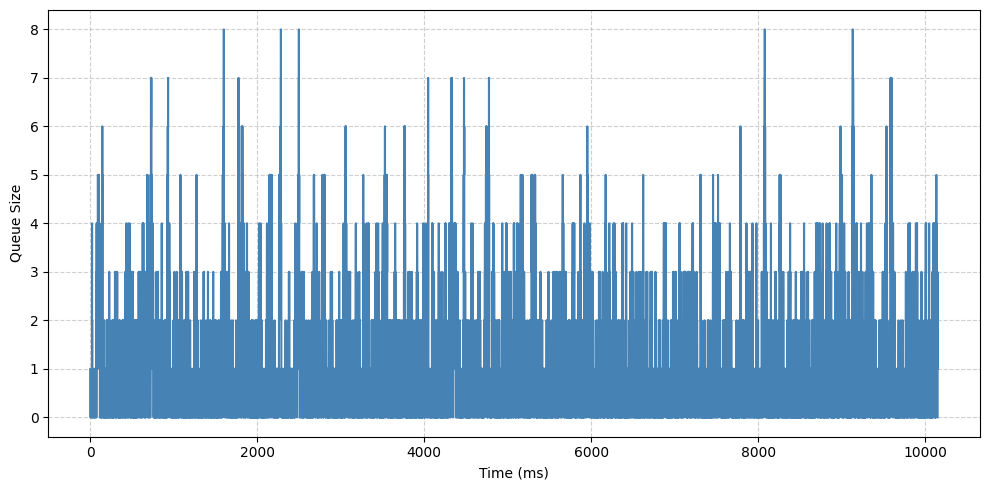

In [ ]:
times = [entry['time_ms'] for entry in queue_size_dict]
sizes = [entry['size'] for entry in queue_size_dict]

plt.figure(figsize=(10, 5))
plt.step(times, sizes, where='post', color='steelblue')

plt.xlabel("Time (ms)")
plt.ylabel("Queue Size")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
time_queue_state = np.zeros(8)

time_diffs = np.diff(times)
time_state = sizes[:-1]

for i in range(len(time_state)):
  idx = time_state[i]-1
  time_queue_state[idx] += time_diffs[i]

In [ ]:
time_queue_state

array([2415.27439338, 1311.24713597,  592.54076028,  271.71503091,
        113.41881385,   39.28217188,   13.83268505, 5391.19948068])

Text(0, 0.5, 'Empirical probability')

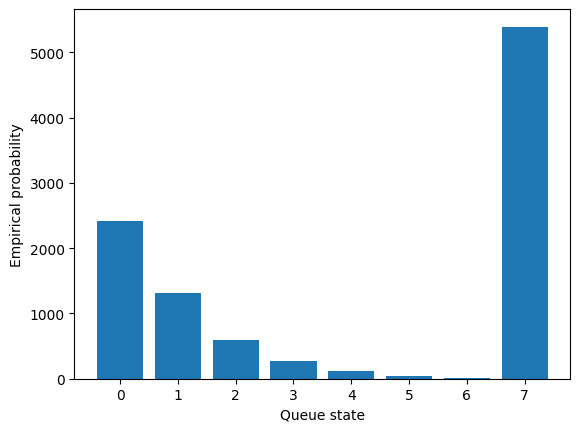

In [ ]:
plt.bar(x=range(8), height=time_queue_state)
plt.xlabel("Queue state")
plt.ylabel("Empirical probability")

In [ ]:
L_q = (time_queue_state*np.arange(0, len(time_queue_state))).sum()/time_queue_state.sum()
L_q

np.float64(4.117151226716891)

### ✅ Queue time matches what the output says?

In [ ]:
L_q / (rps*1e-3)

np.float64(10.447637264785827)

## Queue state transitions

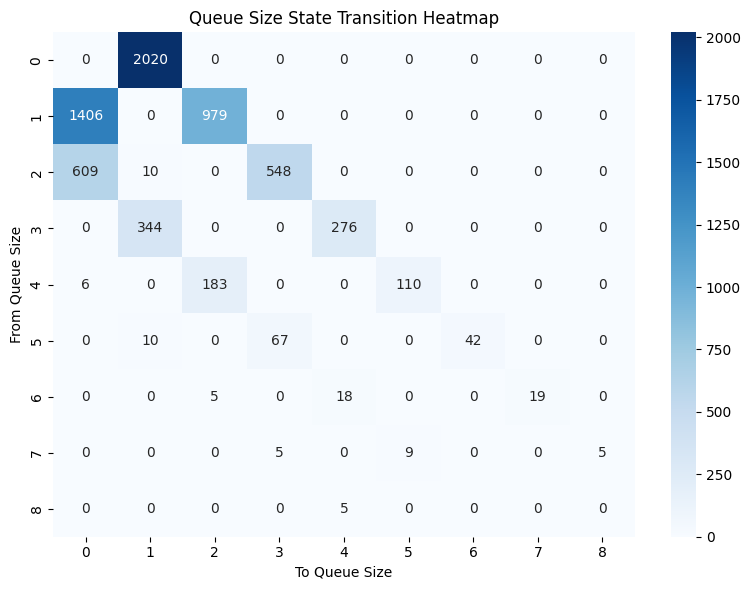

In [ ]:
sizes = [entry['size'] for entry in queue_size_dict]

max_size = max(sizes)
transition_matrix = np.zeros((max_size + 1, max_size + 1), dtype=int)

for i in range(len(sizes) - 1):
    from_size = sizes[i]
    to_size = sizes[i + 1]
    transition_matrix[from_size][to_size] += 1

plt.figure(figsize=(8, 6))
sns.heatmap(transition_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(max_size + 1),
            yticklabels=range(max_size + 1))

plt.xlabel("To Queue Size")
plt.ylabel("From Queue Size")
plt.title("Queue Size State Transition Heatmap")
plt.tight_layout()
plt.show()


### Aggregating traces

In [53]:
import glob

In [55]:
data = []
files = ["trace_test_3a.json", "trace_test_3b.json", "trace_test_3.json", "trace_test_3tail.json"]
for f in glob.glob("trace_dir/*.json"):
    with open (f, "r") as fh:
        data.extend(json.load(fh))

In [56]:
min_ts = data[0]['timestamps'][0]['ns']/1e6
max_ts = data[-1]['timestamps'][0]['ns']/1e6

In [57]:
#get unique sample ids
sids = np.unique([data[i]['id'] for i in range(len(data))])

In [58]:
samples = []
#for each sample get the event names and timestamps (ms) from the moment the first req arrives (min_ts)
#put all samples in a list - each sample has tuples (event, timestamp(ms))
for sidx in sids:
    s = [(data[i]['timestamps'][0]['name'], data[i]['timestamps'][0]['ns']/1e6 - min_ts) for i in range(len(data)) if data[i]['id']==sidx and 'timestamps' in data[i].keys()]
    samples.append(s)

In [59]:
event_list = []
for i in range(len(samples)):
  for event in samples[i]:
    new_dict = {'id':i, 'name':event[0], 'time_ms':event[1]}
    event_list.append(new_dict)
event_list.sort(key=lambda x: x['time_ms'])

In [60]:
samples_dict = []

for sidx in sids:
    sample_dict = {
        data[i]['timestamps'][0]['name']: data[i]['timestamps'][0]['ns'] / 1e6 - min_ts
        for i in range(len(data))
        if data[i]['id'] == sidx and 'timestamps' in data[i]
    }
    samples_dict.append(sample_dict)


### Filter based on measurement window

In [61]:
measurement_window = 5000

In [62]:
last_ts = (max_ts - min_ts) - measurement_window
samples_sub = [s for s in samples_dict if s['REQUEST_START'] >= last_ts]

In [63]:
len(samples_sub)

234

### Compute statistics for filtered subset

In [64]:
queue_times = [s['COMPUTE_START'] - s['QUEUE_START'] for s in samples_sub]

In [65]:
np.mean(queue_times)

np.float64(6.320285630022359)

In [66]:
infer_times = [s['COMPUTE_END'] - s['COMPUTE_START'] for s in samples_sub]

In [67]:
np.mean(infer_times)

np.float64(18.655604448073948)

- tput 47.8
- queue delay 6.8ms
- compute infer 17.8 ms
- 5000 ms measuerment window